# Accuracy Comparison Across Models and Image Types

This notebook visualizes the accuracy of different models (gpt-4o, gpt-5.1, gpt-5.2) for each image type (color, greyscale, inverted greyscale), keeping reasoning and blur settings constant. The data is loaded from the dashboard_data files, and accuracy is computed as the fraction of correct answers per model and image type.

In [39]:
# Data Parsing and Loading
import os
import json
import re
import pandas as pd

dashboard_dir = 'Results/dashboard_data'
all_files = [f for f in os.listdir(dashboard_dir) if f.endswith('.json')]

# Improved regex to handle med_blur, heavy_blur, no_blur, and skills/no_skills
pattern = re.compile(r'llm_results_(?P<image_type>\w+?)_(?P<blur>no_blur|med_blur|heavy_blur)_gpt-4o-gpt-5.1-gpt-5.2_(?P<reasoning>low|medium|high)(?:_(?P<skills>no_skills|skills))?.json')

parsed_files = []
for fname in all_files:
    m = pattern.match(fname)
    if m:
        meta = m.groupdict()
        meta['filename'] = fname
        parsed_files.append(meta)

# Build hierarchical dataframe from parsed_files
records = []
for meta in parsed_files:
    path = os.path.join(dashboard_dir, meta['filename'])
    with open(path, 'r') as f:
        data = json.load(f)
    for key, value in data.items():
        # key: imgX_QY_model
        img_q, model = key.rsplit('_', 1)
        img, q = img_q.split('_Q')
        records.append({
            'image_type': meta['image_type'],
            'blur': meta['blur'],
            'reasoning': meta['reasoning'],
            'skills': meta['skills'],
            'img': img,
            'question': int(q),
            'model': model,
            'correct': value[0],
            'input_tokens': value[1][0],
            'output_tokens': value[1][1],
            'time': value[2]
        })
full_df = pd.DataFrame(records)
print(f"Loaded {len(full_df)} records from {len(parsed_files)} files")

Loaded 3498 records from 47 files


In [49]:
full_df

,image_type,blur,reasoning,skills,img,question,model,correct,input_tokens,output_tokens,time
0,color,heavy_blur,low,no_skills,img1,1,gpt-4o,1,1257.0,77.0,3.926
1,color,heavy_blur,low,no_skills,img1,1,gpt-5.1,1,1061.0,183.0,3.926
2,color,heavy_blur,low,no_skills,img1,1,gpt-5.2,1,1276.0,126.0,3.926
3,color,heavy_blur,low,no_skills,img1,2,gpt-4o,1,1243.0,69.0,2.866
4,color,heavy_blur,low,no_skills,img1,2,gpt-5.1,1,1047.0,183.0,2.866
...,...,...,...,...,...,...,...,...,...,...,...
3493,greyscale,med_blur,low,skills,img8,3,gpt-5.1,0,9906.0,272.0,20.717
3494,greyscale,med_blur,low,skills,img8,3,gpt-5.2,1,11132.0,440.0,20.717
3495,greyscale,med_blur,low,skills,img8,4,gpt-4o,0,9105.0,101.0,7.682
3496,greyscale,med_blur,low,skills,img8,4,gpt-5.1,1,9907.0,462.0,7.682


In [51]:
# Color Images: Multifigure Plot (Plotly Boxplots, legend for all models)
import plotly.graph_objs as go
from plotly.subplots import make_subplots

color_df = full_df[(full_df['image_type'] == 'color') & (full_df['skills'] == 'no_skills')]
model_palette = {'gpt-4o': '#1f77b4', 'gpt-5.1': '#ff7f0e', 'gpt-5.2': '#2ca02c'}
blur_levels = ['no_blur', 'med_blur', 'heavy_blur']
reasoning_levels = ['low', 'medium', 'high']

fig = make_subplots(rows=2, cols=4, subplot_titles=[
    'Blur Level Trend (All Models)',
    'No Blur: Boxplot (Reasoning)',
    'Med Blur: Boxplot (Reasoning)',
    'Heavy Blur: Boxplot (Reasoning)',
    'Reasoning Level Trend (All Models)',
    'Low Reasoning: Boxplot (Blur)',
    'Medium Reasoning: Boxplot (Blur)',
    'High Reasoning: Boxplot (Blur)'
])

# 1. First column, top row: line plot for blur trends
blur_accs = {model: [] for model in model_palette}
for blur_level in blur_levels:
    df_blur = color_df[color_df['blur'] == blur_level]
    accs = df_blur.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        blur_accs[model].append(acc)
x_blur = blur_levels
for model, color in model_palette.items():
    yvals = blur_accs[model]
    fig.add_trace(
        go.Scatter(x=x_blur, y=yvals, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in yvals],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=True),
        row=1, col=1
    )
fig.update_xaxes(title_text='Blur Level', row=1, col=1)
fig.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=1)

# 2. Top row: boxplots for each blur level (distribution across reasoning levels)
for i, blur_level in enumerate(blur_levels):
    df_blur = color_df[color_df['blur'] == blur_level]
    config_groups = df_blur.groupby(['model', 'reasoning'])['correct'].mean().reset_index()
    for model, color in model_palette.items():
        accs = config_groups[config_groups['model'] == model]['correct'].values
        fig.add_trace(
            go.Box(
                y=accs,
                x=[model]*len(accs),
                name=model,
                marker_color=color,
                boxmean='sd',
                boxpoints='all',
                jitter=0.4,
                pointpos=0,
                legendgroup=model,
                showlegend=False,
                line=dict(width=2),
                width=0.5
            ),
            row=1, col=i+2
        )
    fig.update_xaxes(title_text='Model', categoryorder='array', categoryarray=list(model_palette.keys()), row=1, col=i+2)
    fig.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=i+2)

# 3. First column, bottom row: line plot for reasoning trends
reasoning_accs = {model: [] for model in model_palette}
for reasoning_level in reasoning_levels:
    df_reasoning = color_df[color_df['reasoning'] == reasoning_level]
    accs = df_reasoning.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        reasoning_accs[model].append(acc)
x_reason = reasoning_levels
for model, color in model_palette.items():
    yvals = reasoning_accs[model]
    fig.add_trace(
        go.Scatter(x=x_reason, y=yvals, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in yvals],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=False),
        row=2, col=1
    )
fig.update_xaxes(title_text='Reasoning Level', row=2, col=1)
fig.update_yaxes(title_text='Accuracy', range=[0,1], row=2, col=1)

# 4. Bottom row: boxplots for each reasoning level (distribution across blur levels)
for i, reasoning_level in enumerate(reasoning_levels):
    df_reasoning = color_df[color_df['reasoning'] == reasoning_level]
    config_groups = df_reasoning.groupby(['model', 'blur'])['correct'].mean().reset_index()
    for model, color in model_palette.items():
        accs = config_groups[config_groups['model'] == model]['correct'].values
        fig.add_trace(
            go.Box(
                y=accs,
                x=[model]*len(accs),
                name=model,
                marker_color=color,
                boxmean='sd',
                boxpoints='all',
                jitter=0.4,
                pointpos=0,
                legendgroup=model,
                showlegend=False,
                line=dict(width=2),
                width=0.5
            ),
            row=2, col=i+2
        )
    fig.update_xaxes(title_text='Model', categoryorder='array', categoryarray=list(model_palette.keys()), row=2, col=i+2)
    fig.update_yaxes(title_text='Accuracy', range=[0,1], row=2, col=i+2)

fig.update_layout(
    height=900, width=2400,
    title_text='Color Images: Model Accuracy Trends and Distributions',
    boxmode='group',
    legend_title_text='Model',
    margin=dict(t=60, b=40),
    font=dict(size=14),
)
fig.show()

In [41]:
# Greyscale Images: Multifigure Plot (Plotly Boxplots, legend for all models)
import plotly.graph_objs as go
from plotly.subplots import make_subplots

greyscale_df = full_df[(full_df['image_type'] == 'greyscale') & (full_df['skills'] == 'no_skills')]
model_palette = {'gpt-4o': '#1f77b4', 'gpt-5.1': '#ff7f0e', 'gpt-5.2': '#2ca02c'}
blur_levels = ['no_blur', 'med_blur', 'heavy_blur']
reasoning_levels = ['low', 'medium', 'high']

fig = make_subplots(rows=2, cols=4, subplot_titles=[
    'Blur Level Trend (All Models)',
    'No Blur: Boxplot (Reasoning)',
    'Med Blur: Boxplot (Reasoning)',
    'Heavy Blur: Boxplot (Reasoning)',
    'Reasoning Level Trend (All Models)',
    'Low Reasoning: Boxplot (Blur)',
    'Medium Reasoning: Boxplot (Blur)',
    'High Reasoning: Boxplot (Blur)'
])

# 1. First column, top row: line plot for blur trends
blur_accs = {model: [] for model in model_palette}
for blur_level in blur_levels:
    df_blur = greyscale_df[greyscale_df['blur'] == blur_level]
    accs = df_blur.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        blur_accs[model].append(acc)
x_blur = blur_levels
for model, color in model_palette.items():
    yvals = blur_accs[model]
    fig.add_trace(
        go.Scatter(x=x_blur, y=yvals, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in yvals],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=True),
        row=1, col=1
    )
fig.update_xaxes(title_text='Blur Level', row=1, col=1)
fig.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=1)

# 2. Top row: boxplots for each blur level (distribution across reasoning levels)
for i, blur_level in enumerate(blur_levels):
    df_blur = greyscale_df[greyscale_df['blur'] == blur_level]
    config_groups = df_blur.groupby(['model', 'reasoning'])['correct'].mean().reset_index()
    for model, color in model_palette.items():
        accs = config_groups[config_groups['model'] == model]['correct'].values
        fig.add_trace(
            go.Box(
                y=accs,
                x=[model]*len(accs),
                name=model,
                marker_color=color,
                boxmean='sd',
                boxpoints='all',
                jitter=0.4,
                pointpos=0,
                legendgroup=model,
                showlegend=False,
                line=dict(width=2),
                width=0.5
            ),
            row=1, col=i+2
        )
    fig.update_xaxes(title_text='Model', categoryorder='array', categoryarray=list(model_palette.keys()), row=1, col=i+2)
    fig.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=i+2)

# 3. First column, bottom row: line plot for reasoning trends
reasoning_accs = {model: [] for model in model_palette}
for reasoning_level in reasoning_levels:
    df_reasoning = greyscale_df[greyscale_df['reasoning'] == reasoning_level]
    accs = df_reasoning.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        reasoning_accs[model].append(acc)
x_reason = reasoning_levels
for model, color in model_palette.items():
    yvals = reasoning_accs[model]
    fig.add_trace(
        go.Scatter(x=x_reason, y=yvals, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in yvals],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=False),
        row=2, col=1
    )
fig.update_xaxes(title_text='Reasoning Level', row=2, col=1)
fig.update_yaxes(title_text='Accuracy', range=[0,1], row=2, col=1)

# 4. Bottom row: boxplots for each reasoning level (distribution across blur levels)
for i, reasoning_level in enumerate(reasoning_levels):
    df_reasoning = greyscale_df[greyscale_df['reasoning'] == reasoning_level]
    config_groups = df_reasoning.groupby(['model', 'blur'])['correct'].mean().reset_index()
    for model, color in model_palette.items():
        accs = config_groups[config_groups['model'] == model]['correct'].values
        fig.add_trace(
            go.Box(
                y=accs,
                x=[model]*len(accs),
                name=model,
                marker_color=color,
                boxmean='sd',
                boxpoints='all',
                jitter=0.4,
                pointpos=0,
                legendgroup=model,
                showlegend=False,
                line=dict(width=2),
                width=0.5
            ),
            row=2, col=i+2
        )
    fig.update_xaxes(title_text='Model', categoryorder='array', categoryarray=list(model_palette.keys()), row=2, col=i+2)
    fig.update_yaxes(title_text='Accuracy', range=[0,1], row=2, col=i+2)

fig.update_layout(
    height=900, width=2400,
    title_text='Greyscale Images: Model Accuracy Trends and Distributions',
    boxmode='group',
    legend_title_text='Model',
    margin=dict(t=60, b=40),
    font=dict(size=14),
)
fig.show()

In [42]:

# Inverted Greyscale Images: Multifigure Plot (Plotly Boxplots, legend for all models)
import plotly.graph_objs as go
from plotly.subplots import make_subplots

inverted_df = full_df[(full_df['image_type'] == 'inverted_greyscale') & (full_df['skills'] == 'no_skills')]
model_palette = {'gpt-4o': '#1f77b4', 'gpt-5.1': '#ff7f0e', 'gpt-5.2': '#2ca02c'}
blur_levels = ['no_blur', 'med_blur', 'heavy_blur']
reasoning_levels = ['low', 'medium', 'high']

fig = make_subplots(rows=2, cols=4, subplot_titles=[
    'Blur Level Trend (All Models)',
    'No Blur: Boxplot (Reasoning)',
    'Med Blur: Boxplot (Reasoning)',
    'Heavy Blur: Boxplot (Reasoning)',
    'Reasoning Level Trend (All Models)',
    'Low Reasoning: Boxplot (Blur)',
    'Medium Reasoning: Boxplot (Blur)',
    'High Reasoning: Boxplot (Blur)'
])

# 1. First column, top row: line plot for blur trends
blur_accs = {model: [] for model in model_palette}
for blur_level in blur_levels:
    df_blur = inverted_df[inverted_df['blur'] == blur_level]
    accs = df_blur.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        blur_accs[model].append(acc)
x_blur = blur_levels
for model, color in model_palette.items():
    yvals = blur_accs[model]
    fig.add_trace(
        go.Scatter(x=x_blur, y=yvals, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in yvals],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=True),
        row=1, col=1
    )
fig.update_xaxes(title_text='Blur Level', row=1, col=1)
fig.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=1)

# 2. Top row: boxplots for each blur level (distribution across reasoning levels)
for i, blur_level in enumerate(blur_levels):
    df_blur = inverted_df[inverted_df['blur'] == blur_level]
    config_groups = df_blur.groupby(['model', 'reasoning'])['correct'].mean().reset_index()
    for model, color in model_palette.items():
        accs = config_groups[config_groups['model'] == model]['correct'].values
        fig.add_trace(
            go.Box(
                y=accs,
                x=[model]*len(accs),
                name=model,
                marker_color=color,
                boxmean='sd',
                boxpoints='all',
                jitter=0.4,
                pointpos=0,
                legendgroup=model,
                showlegend=False,
                line=dict(width=2),
                width=0.5
            ),
            row=1, col=i+2
        )
    fig.update_xaxes(title_text='Model', categoryorder='array', categoryarray=list(model_palette.keys()), row=1, col=i+2)
    fig.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=i+2)

# 3. First column, bottom row: line plot for reasoning trends
reasoning_accs = {model: [] for model in model_palette}
for reasoning_level in reasoning_levels:
    df_reasoning = inverted_df[inverted_df['reasoning'] == reasoning_level]
    accs = df_reasoning.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        reasoning_accs[model].append(acc)
x_reason = reasoning_levels
for model, color in model_palette.items():
    yvals = reasoning_accs[model]
    fig.add_trace(
        go.Scatter(x=x_reason, y=yvals, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in yvals],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=False),
        row=2, col=1
    )
fig.update_xaxes(title_text='Reasoning Level', row=2, col=1)
fig.update_yaxes(title_text='Accuracy', range=[0,1], row=2, col=1)

# 4. Bottom row: boxplots for each reasoning level (distribution across blur levels)
for i, reasoning_level in enumerate(reasoning_levels):
    df_reasoning = inverted_df[inverted_df['reasoning'] == reasoning_level]
    config_groups = df_reasoning.groupby(['model', 'blur'])['correct'].mean().reset_index()
    for model, color in model_palette.items():
        accs = config_groups[config_groups['model'] == model]['correct'].values
        fig.add_trace(
            go.Box(
                y=accs,
                x=[model]*len(accs),
                name=model,
                marker_color=color,
                boxmean='sd',
                boxpoints='all',
                jitter=0.4,
                pointpos=0,
                legendgroup=model,
                showlegend=False,
                line=dict(width=2),
                width=0.5
            ),
            row=2, col=i+2
        )
    fig.update_xaxes(title_text='Model', categoryorder='array', categoryarray=list(model_palette.keys()), row=2, col=i+2)
    fig.update_yaxes(title_text='Accuracy', range=[0,1], row=2, col=i+2)

fig.update_layout(
    height=900, width=2400,
    title_text='Inverted Greyscale Images: Model Accuracy Trends and Distributions',
    boxmode='group',
    legend_title_text='Model',
    margin=dict(t=60, b=40),
    font=dict(size=14),
)
fig.show()

In [43]:
# Boxplots: Model Accuracy Distributions with Hover Details (Color Images)
import plotly.express as px
# Prepare config-level accuracy data for color images
color_config_acc = color_df.groupby(['model', 'blur', 'reasoning'])['correct'].mean().reset_index()

# 1. Multifigure: Boxplot faceted by blur level
fig_blur = px.box(color_config_acc,
    x='model', y='correct', color='model',
    facet_col='blur',
    points='all',
    color_discrete_map=model_palette,
    category_orders={'blur': ['no_blur', 'med_blur', 'heavy_blur'], 'model': list(model_palette.keys())},
    hover_data=['blur', 'reasoning'],
    title='Model Accuracy Distribution by Blur Level (Boxplot)')
for axis in fig_blur.layout['yaxis'], fig_blur.layout['yaxis2'], fig_blur.layout['yaxis3']:
    axis.range = [0, 1]
fig_blur.show()

# 2. Multifigure: Boxplot faceted by reasoning level
fig_reasoning = px.box(color_config_acc,
    x='model', y='correct', color='model',
    facet_col='reasoning',
    points='all',
    color_discrete_map=model_palette,
    category_orders={'reasoning': ['low', 'medium', 'high'], 'model': list(model_palette.keys())},
    hover_data=['blur', 'reasoning'],
    title='Model Accuracy Distribution by Reasoning Level (Boxplot)')
for axis in fig_reasoning.layout['yaxis'], fig_reasoning.layout['yaxis2'], fig_reasoning.layout['yaxis3']:
    axis.range = [0, 1]
fig_reasoning.show()

In [44]:
# Boxplots: Model Accuracy Distributions with Hover Details (Greyscale Images) and Trend Plots
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Prepare config-level accuracy data for greyscale images
greyscale_config_acc = greyscale_df.groupby(['model', 'blur', 'reasoning'])['correct'].mean().reset_index()

# 0. Trend plots for greyscale images
fig_trend = make_subplots(rows=1, cols=2, subplot_titles=['Blur Level Trend (All Models)', 'Reasoning Level Trend (All Models)'])
for model, color in model_palette.items():
    # Blur trend
    blur_accs = []
    for blur_level in blur_levels:
        acc = greyscale_df[(greyscale_df['blur'] == blur_level) & (greyscale_df['model'] == model)]['correct'].mean()
        blur_accs.append(acc)
    fig_trend.add_trace(
        go.Scatter(x=blur_levels, y=blur_accs, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in blur_accs],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=True),
        row=1, col=1
    )
    # Reasoning trend
    reasoning_accs = []
    for reasoning_level in reasoning_levels:
        acc = greyscale_df[(greyscale_df['reasoning'] == reasoning_level) & (greyscale_df['model'] == model)]['correct'].mean()
        reasoning_accs.append(acc)
    fig_trend.add_trace(
        go.Scatter(x=reasoning_levels, y=reasoning_accs, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in reasoning_accs],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=False),
        row=1, col=2
    )
fig_trend.update_xaxes(title_text='Blur Level', row=1, col=1)
fig_trend.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=1)
fig_trend.update_xaxes(title_text='Reasoning Level', row=1, col=2)
fig_trend.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=2)
fig_trend.update_layout(height=400, width=1200, title_text='Greyscale Images: Model Accuracy Trends', font=dict(size=14), margin=dict(t=60, b=40))
fig_trend.show()

# 1. Multifigure: Boxplot faceted by blur level
fig_blur = px.box(greyscale_config_acc,
    x='model', y='correct', color='model',
    facet_col='blur',
    points='all',
    color_discrete_map=model_palette,
    category_orders={'blur': ['no_blur', 'med_blur', 'heavy_blur'], 'model': list(model_palette.keys())},
    hover_data=['blur', 'reasoning'],
    title='Greyscale: Model Accuracy Distribution by Blur Level (Boxplot)')
for axis in fig_blur.layout['yaxis'], fig_blur.layout['yaxis2'], fig_blur.layout['yaxis3']:
    axis.range = [0, 1]
fig_blur.show()

# 2. Multifigure: Boxplot faceted by reasoning level
fig_reasoning = px.box(greyscale_config_acc,
    x='model', y='correct', color='model',
    facet_col='reasoning',
    points='all',
    color_discrete_map=model_palette,
    category_orders={'reasoning': ['low', 'medium', 'high'], 'model': list(model_palette.keys())},
    hover_data=['blur', 'reasoning'],
    title='Greyscale: Model Accuracy Distribution by Reasoning Level (Boxplot)')
for axis in fig_reasoning.layout['yaxis'], fig_reasoning.layout['yaxis2'], fig_reasoning.layout['yaxis3']:
    axis.range = [0, 1]
fig_reasoning.show()
# Boxplots: Model Accuracy Distributions with Hover Details (Inverted Greyscale Images) and Trend Plots
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Prepare config-level accuracy data for inverted greyscale images
inverted_config_acc = inverted_df.groupby(['model', 'blur', 'reasoning'])['correct'].mean().reset_index()

# 0. Trend plots for inverted greyscale images
fig_trend = make_subplots(rows=1, cols=2, subplot_titles=['Blur Level Trend (All Models)', 'Reasoning Level Trend (All Models)'])
for model, color in model_palette.items():
    # Blur trend
    blur_accs = []
    for blur_level in blur_levels:
        acc = inverted_df[(inverted_df['blur'] == blur_level) & (inverted_df['model'] == model)]['correct'].mean()
        blur_accs.append(acc)
    fig_trend.add_trace(
        go.Scatter(x=blur_levels, y=blur_accs, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in blur_accs],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=True),
        row=1, col=1
    )
    # Reasoning trend
    reasoning_accs = []
    for reasoning_level in reasoning_levels:
        acc = inverted_df[(inverted_df['reasoning'] == reasoning_level) & (inverted_df['model'] == model)]['correct'].mean()
        reasoning_accs.append(acc)
    fig_trend.add_trace(
        go.Scatter(x=reasoning_levels, y=reasoning_accs, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in reasoning_accs],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=False),
        row=1, col=2
    )
fig_trend.update_xaxes(title_text='Blur Level', row=1, col=1)
fig_trend.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=1)
fig_trend.update_xaxes(title_text='Reasoning Level', row=1, col=2)
fig_trend.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=2)
fig_trend.update_layout(height=400, width=1200, title_text='Inverted Greyscale Images: Model Accuracy Trends', font=dict(size=14), margin=dict(t=60, b=40))
fig_trend.show()

# 1. Multifigure: Boxplot faceted by blur level
fig_blur = px.box(inverted_config_acc,
    x='model', y='correct', color='model',
    facet_col='blur',
    points='all',
    color_discrete_map=model_palette,
    category_orders={'blur': ['no_blur', 'med_blur', 'heavy_blur'], 'model': list(model_palette.keys())},
    hover_data=['blur', 'reasoning'],
    title='Inverted Greyscale: Model Accuracy Distribution by Blur Level (Boxplot)')
for axis in fig_blur.layout['yaxis'], fig_blur.layout['yaxis2'], fig_blur.layout['yaxis3']:
    axis.range = [0, 1]
fig_blur.show()

# 2. Multifigure: Boxplot faceted by reasoning level
fig_reasoning = px.box(inverted_config_acc,
    x='model', y='correct', color='model',
    facet_col='reasoning',
    points='all',
    color_discrete_map=model_palette,
    category_orders={'reasoning': ['low', 'medium', 'high'], 'model': list(model_palette.keys())},
    hover_data=['blur', 'reasoning'],
    title='Inverted Greyscale: Model Accuracy Distribution by Reasoning Level (Boxplot)')
for axis in fig_reasoning.layout['yaxis'], fig_reasoning.layout['yaxis2'], fig_reasoning.layout['yaxis3']:
    axis.range = [0, 1]
fig_reasoning.show()

In [45]:
# Alternative Visualizations for Model Accuracy Distributions (Color Images)
import plotly.express as px
import plotly.graph_objs as go
import pandas as pd

# Prepare config-level accuracy data for color images
color_config_acc = color_df.groupby(['model', 'blur', 'reasoning'])['correct'].mean().reset_index()

# 0. Line plot: Model accuracy trends by blur and reasoning (all models)
import plotly.subplots as sp

fig_line = sp.make_subplots(rows=1, cols=2, subplot_titles=['Blur Level Trend (All Models)', 'Reasoning Level Trend (All Models)'])

# Blur trend
blur_levels = ['no_blur', 'med_blur', 'heavy_blur']
reasoning_levels = ['low', 'medium', 'high']
for model, color in model_palette.items():
    blur_accs = []
    for blur_level in blur_levels:
        acc = color_df[(color_df['blur'] == blur_level) & (color_df['model'] == model)]['correct'].mean()
        blur_accs.append(acc)
    fig_line.add_trace(
        go.Scatter(x=blur_levels, y=blur_accs, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in blur_accs],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=True if model == 'gpt-4o' else False),
        row=1, col=1
    )
fig_line.update_xaxes(title_text='Blur Level', row=1, col=1)
fig_line.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=1)

# Reasoning trend
for model, color in model_palette.items():
    reasoning_accs = []
    for reasoning_level in reasoning_levels:
        acc = color_df[(color_df['reasoning'] == reasoning_level) & (color_df['model'] == model)]['correct'].mean()
        reasoning_accs.append(acc)
    fig_line.add_trace(
        go.Scatter(x=reasoning_levels, y=reasoning_accs, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in reasoning_accs],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=False),
        row=1, col=2
    )
fig_line.update_xaxes(title_text='Reasoning Level', row=1, col=2)
fig_line.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=2)

fig_line.update_layout(height=400, width=1200, title_text='Model Accuracy Trends (Color Images)', font=dict(size=14), margin=dict(t=60, b=40))
fig_line.show()

# 1. Faceted boxplot: Model accuracy by blur and reasoning (facet by blur, color by model)
fig1 = px.box(color_config_acc, 
               x='reasoning', y='correct', color='model', 
               facet_col='blur', 
               category_orders={'blur': ['no_blur', 'med_blur', 'heavy_blur'], 'reasoning': ['low', 'medium', 'high'], 'model': list(model_palette.keys())},
               color_discrete_map=model_palette,
               title='Model Accuracy by Reasoning (Faceted by Blur)',
               points='all',
               boxmode='group')
fig1.update_yaxes(range=[0,1])
fig1.show()

# 3. Strip plot: All config accuracies by model
fig3 = px.strip(color_config_acc, 
                x='model', y='correct', 
                color='model', 
                color_discrete_map=model_palette, 
                title='Distribution of Config Accuracies by Model',
                hover_data=['blur', 'reasoning'])
fig3.update_yaxes(range=[0,1])
fig3.show()

# 4. Violin plot: Model accuracy distributions
fig4 = px.violin(color_config_acc, 
                 x='model', y='correct', 
                 color='model', 
                 box=True, 
                 points='all', 
                 color_discrete_map=model_palette, 
                 title='Model Accuracy Distribution (Violin Plot)')
fig4.update_yaxes(range=[0,1])
fig4.show()

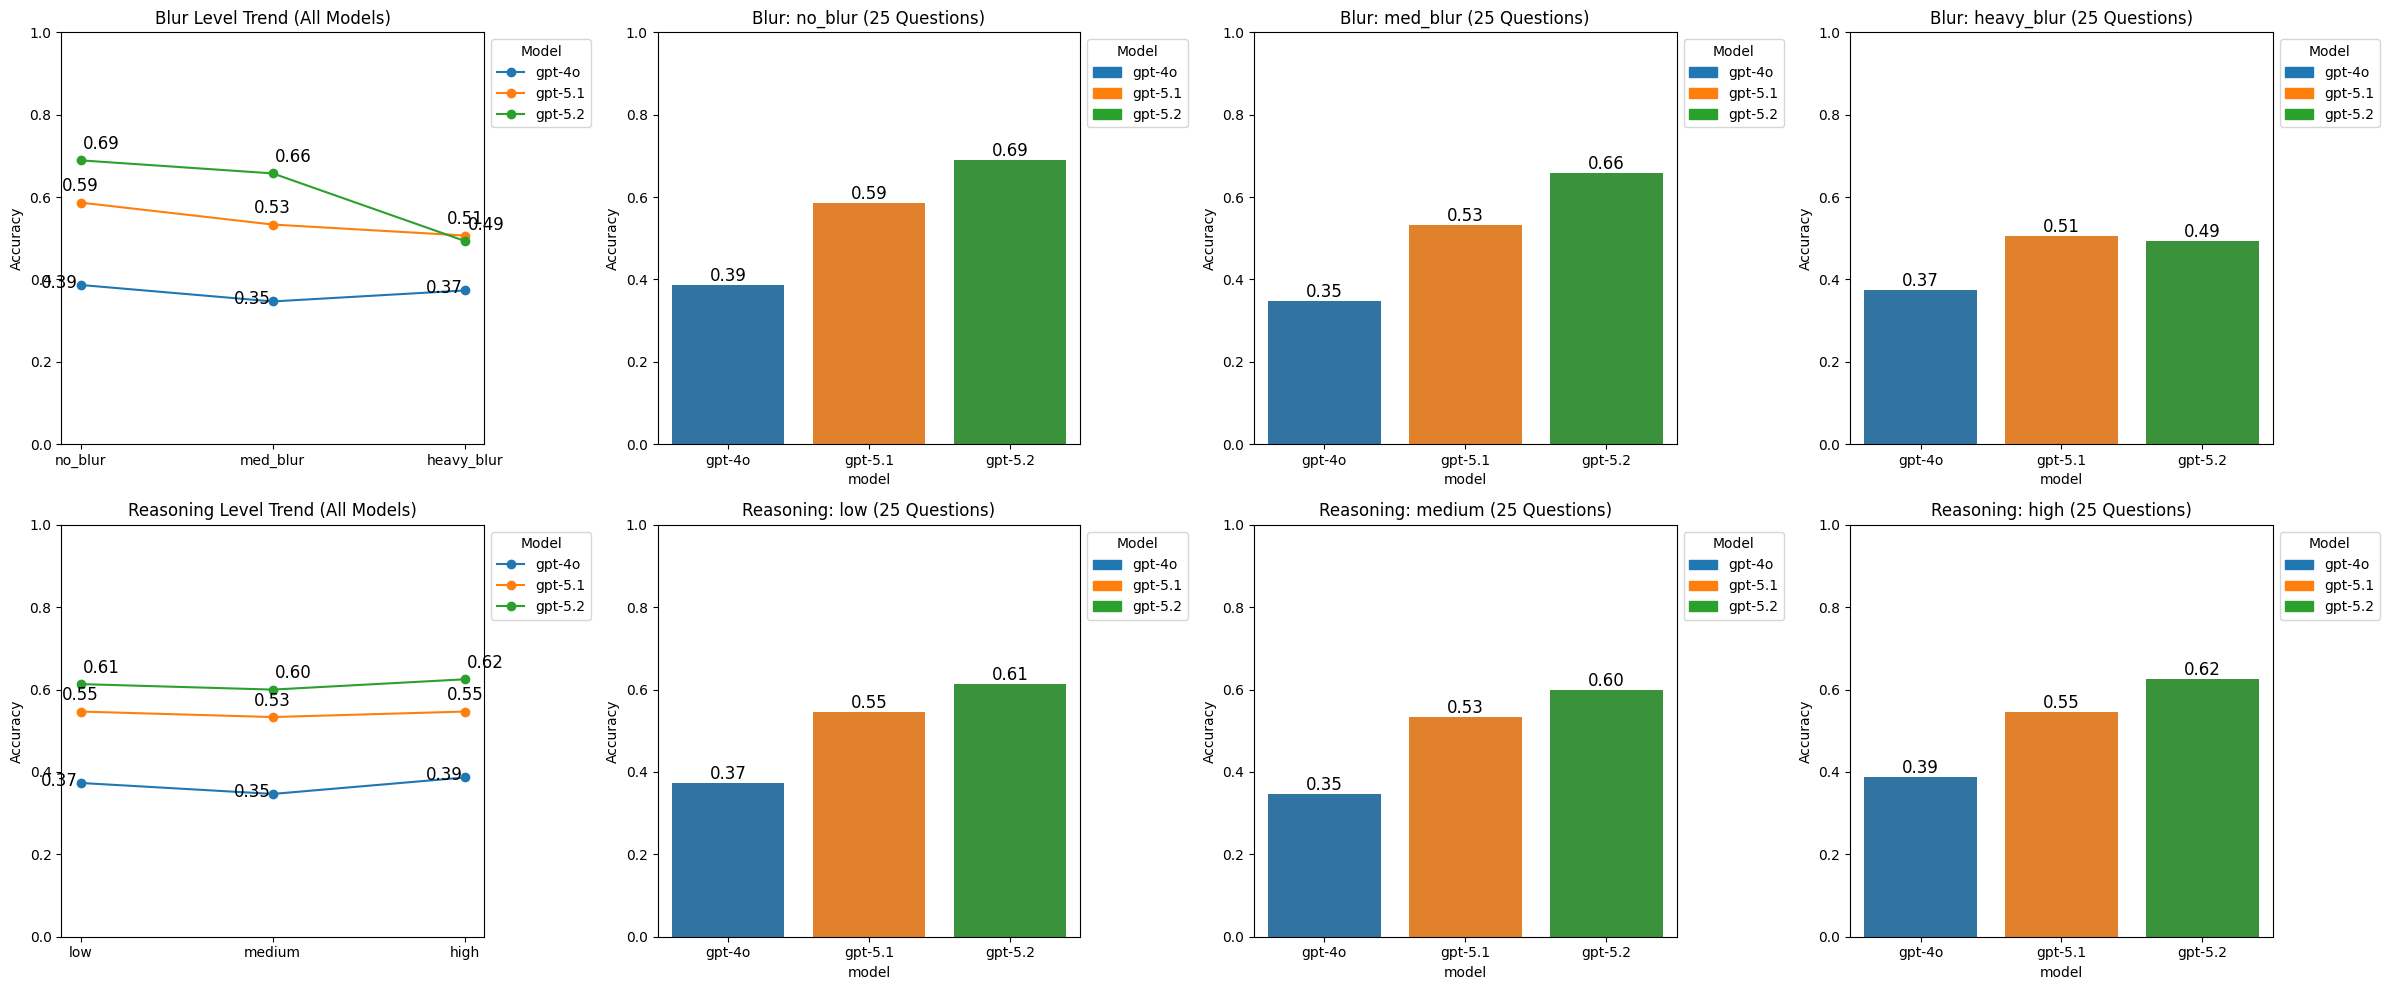

In [46]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
# Greyscale Images: Multifigure Plot (Line plot first, then boxplots, legend for all models)
greyscale_df = full_df[(full_df['image_type'] == 'greyscale') & (full_df['skills'] == 'no_skills')]
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
blur_levels = ['no_blur', 'med_blur', 'heavy_blur']
reasoning_levels = ['low', 'medium', 'high']
model_vertical_offsets = {'gpt-4o': -10, 'gpt-5.1': 0, 'gpt-5.2': 0}

# 1. First plot: line plot for blur trends (all models)
blur_accs = {model: [] for model in model_palette}
for blur_level in blur_levels:
    df_blur = greyscale_df[greyscale_df['blur'] == blur_level]
    accs = df_blur.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        blur_accs[model].append(acc)
for idx, (model, color) in enumerate(model_palette.items()):
    yvals = blur_accs[model]
    axes[0, 0].plot(blur_levels, yvals, marker='o', color=color, label=model)
    for j, y in enumerate(yvals):
        h_offset = (-15 + 15*idx) if len(model_palette) > 1 else 0
        v_offset = model_vertical_offsets[model]
        axes[0, 0].annotate(f'{y:.2f}', (blur_levels[j], y), textcoords="offset points", xytext=(h_offset,8+v_offset), ha='center', fontsize=12)
axes[0, 0].set_title('Blur Level Trend (All Models)')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend(title='Model', loc='upper left', bbox_to_anchor=(1, 1))

# 2. Top row: boxplots for each blur level (distribution across reasoning levels)
for i, blur_level in enumerate(blur_levels):
    df_blur = greyscale_df[greyscale_df['blur'] == blur_level]
    accs = df_blur.groupby('model')['correct'].mean().reset_index()
    ax = sns.barplot(data=accs, x='model', y='correct', hue='model', palette=model_palette, legend=False, ax=axes[0, i+1])
    axes[0, i+1].set_title(f'Blur: {blur_level} (25 Questions)')
    axes[0, i+1].set_ylabel('Accuracy')
    axes[0, i+1].set_ylim(0, 1)
    for p, model in zip(ax.patches, accs['model']):
        height = p.get_height()
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=12)
    handles = [plt.Rectangle((0,0),1,1, color=model_palette[m]) for m in model_palette]
    axes[0, i+1].legend(handles, model_palette.keys(), title='Model', loc='upper left', bbox_to_anchor=(1, 1))

# 3. First column, bottom row: line plot for reasoning trends
reasoning_accs = {model: [] for model in model_palette}
for reasoning_level in reasoning_levels:
    df_reasoning = greyscale_df[greyscale_df['reasoning'] == reasoning_level]
    accs = df_reasoning.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        reasoning_accs[model].append(acc)
for idx, (model, color) in enumerate(model_palette.items()):
    yvals = reasoning_accs[model]
    axes[1, 0].plot(reasoning_levels, yvals, marker='o', color=color, label=model)
    for j, y in enumerate(yvals):
        h_offset = (-15 + 15*idx) if len(model_palette) > 1 else 0
        v_offset = model_vertical_offsets[model]
        axes[1, 0].annotate(f'{y:.2f}', (reasoning_levels[j], y), textcoords="offset points", xytext=(h_offset,8+v_offset), ha='center', fontsize=12)
axes[1, 0].set_title('Reasoning Level Trend (All Models)')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend(title='Model', loc='upper left', bbox_to_anchor=(1, 1))

# 4. Bottom row: boxplots for each reasoning level (distribution across blur levels)
for i, reasoning_level in enumerate(reasoning_levels):
    df_reasoning = greyscale_df[greyscale_df['reasoning'] == reasoning_level]
    accs = df_reasoning.groupby('model')['correct'].mean().reset_index()
    ax = sns.barplot(data=accs, x='model', y='correct', hue='model', palette=model_palette, legend=False, ax=axes[1, i+1])
    axes[1, i+1].set_title(f'Reasoning: {reasoning_level} (25 Questions)')
    axes[1, i+1].set_ylabel('Accuracy')
    axes[1, i+1].set_ylim(0, 1)
    for p, model in zip(ax.patches, accs['model']):
        height = p.get_height()
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=12)
    handles = [plt.Rectangle((0,0),1,1, color=model_palette[m]) for m in model_palette]
    axes[1, i+1].legend(handles, model_palette.keys(), title='Model', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

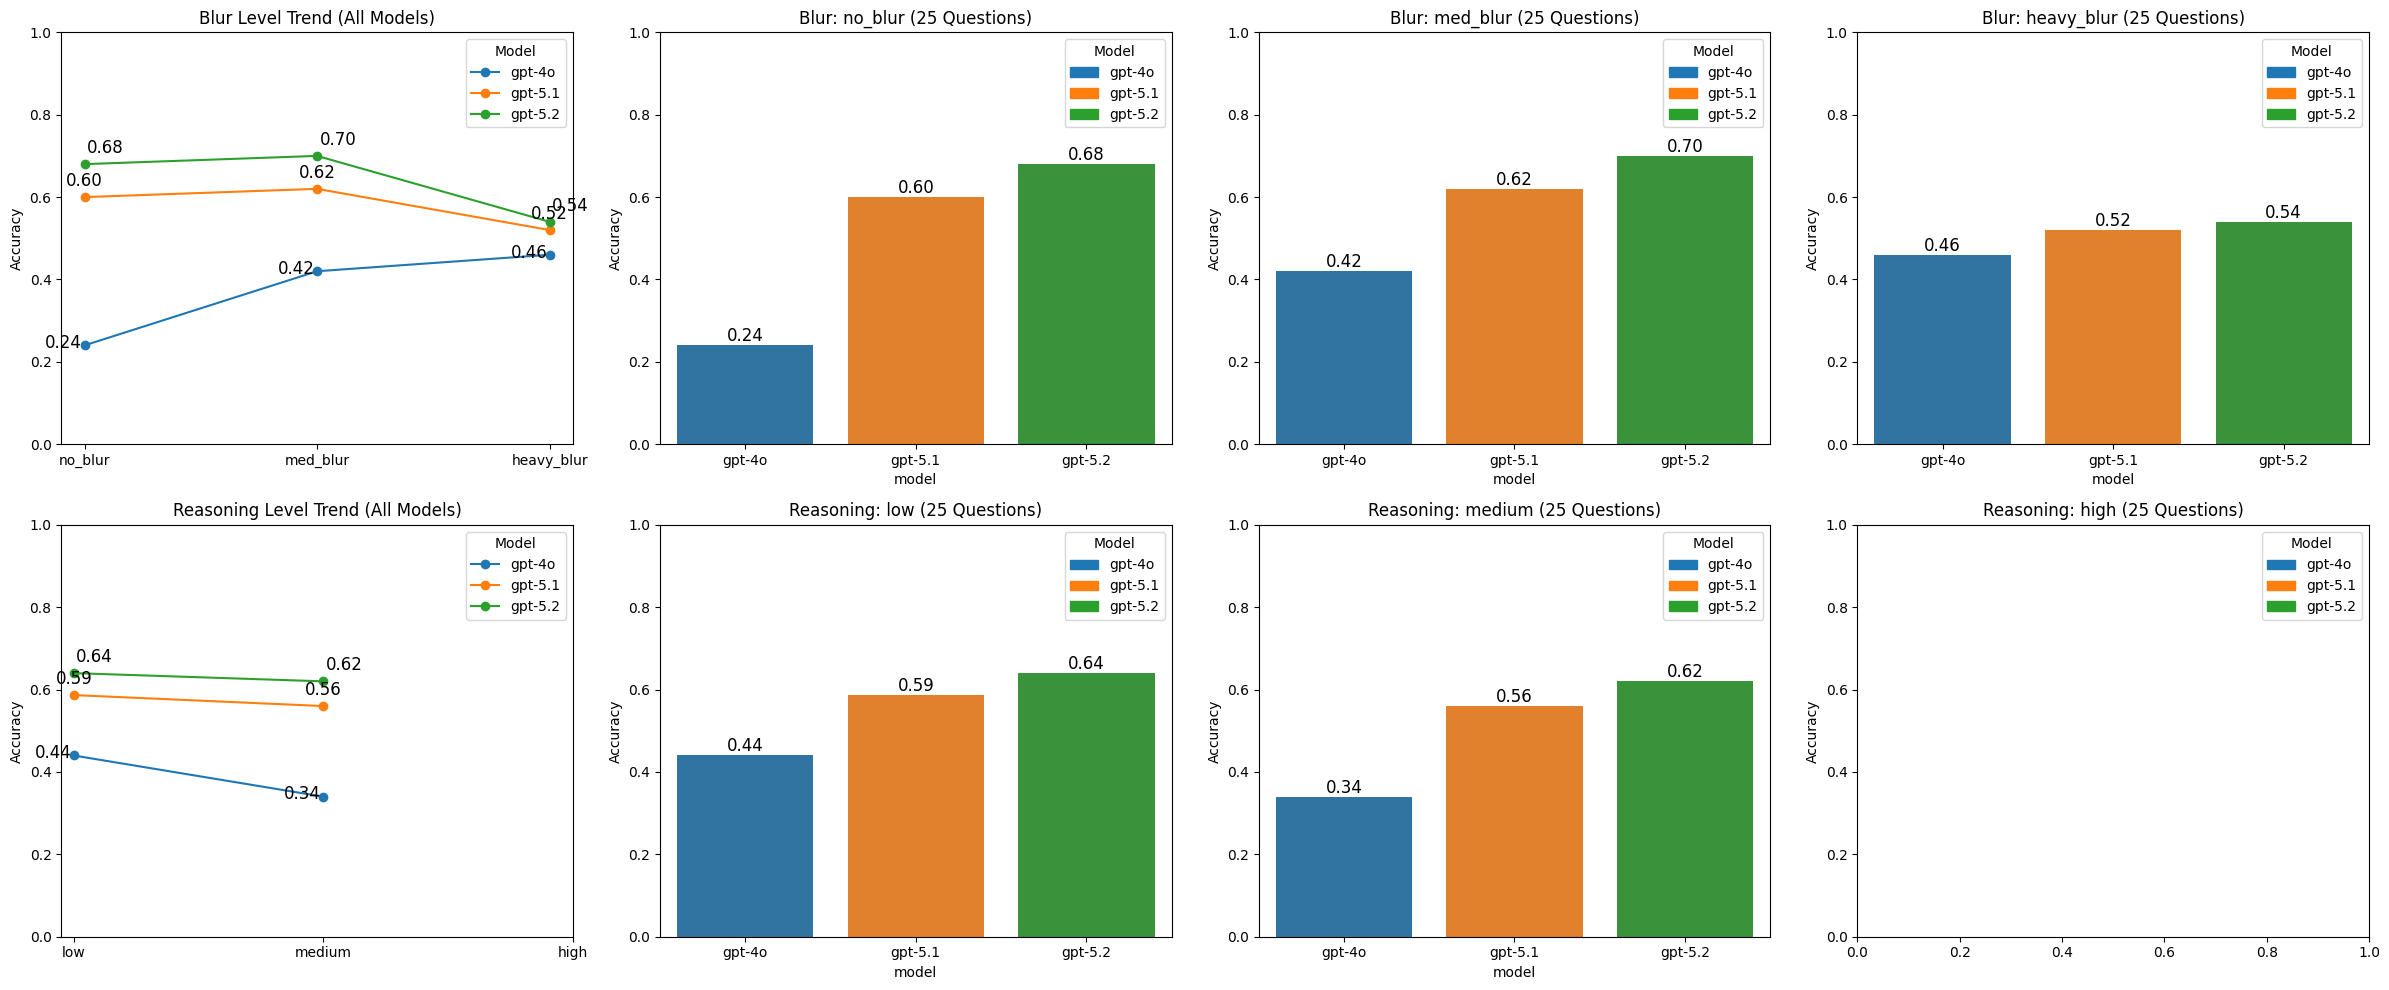

In [47]:
import numpy as np
# Inverted Greyscale Images: Multifigure Plot
inverted_df = full_df[(full_df['image_type'] == 'inverted_greyscale') & (full_df['skills'] == 'no_skills')]
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
blur_levels = ['no_blur', 'med_blur', 'heavy_blur']
reasoning_levels = ['low', 'medium', 'high']
model_vertical_offsets = {'gpt-4o': -10, 'gpt-5.1': 0, 'gpt-5.2': 0}

blur_accs = {model: [] for model in model_palette}
for i, blur_level in enumerate(blur_levels):
    df_blur = inverted_df[inverted_df['blur'] == blur_level]
    accs = df_blur.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        blur_accs[model].append(acc)
x_blur = np.arange(len(blur_levels))
for idx, (model, color) in enumerate(model_palette.items()):
    yvals = blur_accs[model]
    axes[0, 0].plot(x_blur, yvals, marker='o', color=color, label=model)
    for j, y in enumerate(yvals):
        h_offset = (-15 + 15*idx) if len(model_palette) > 1 else 0
        v_offset = model_vertical_offsets[model]
        axes[0, 0].annotate(f'{y:.2f}', (x_blur[j], y), textcoords="offset points", xytext=(h_offset,8+v_offset), ha='center', fontsize=12)
axes[0, 0].set_xticks(x_blur)
axes[0, 0].set_xticklabels(blur_levels)
axes[0, 0].set_title('Blur Level Trend (All Models)')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend(title='Model')

for i, blur_level in enumerate(blur_levels):
    df_blur = inverted_df[inverted_df['blur'] == blur_level]
    accs = df_blur.groupby('model')['correct'].mean().reset_index()
    ax = sns.barplot(data=accs, x='model', y='correct', hue='model', palette=model_palette, legend=False, ax=axes[0, i+1])
    axes[0, i+1].set_title(f'Blur: {blur_level} (25 Questions)')
    axes[0, i+1].set_ylabel('Accuracy')
    axes[0, i+1].set_ylim(0, 1)
    for p, model in zip(ax.patches, accs['model']):
        height = p.get_height()
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=12)
    handles = [plt.Rectangle((0,0),1,1, color=model_palette[m]) for m in model_palette]
    axes[0, i+1].legend(handles, model_palette.keys(), title='Model')

reasoning_accs = {model: [] for model in model_palette}
for i, reasoning_level in enumerate(reasoning_levels):
    df_reasoning = inverted_df[inverted_df['reasoning'] == reasoning_level]
    accs = df_reasoning.groupby('model')['correct'].mean().reindex(model_palette.keys()).reset_index()
    for model, acc in zip(accs['model'], accs['correct']):
        reasoning_accs[model].append(acc)
x_reason = np.arange(len(reasoning_levels))
for idx, (model, color) in enumerate(model_palette.items()):
    yvals = reasoning_accs[model]
    axes[1, 0].plot(x_reason, yvals, marker='o', color=color, label=model)
    for j, y in enumerate(yvals):
        h_offset = (-15 + 15*idx) if len(model_palette) > 1 else 0
        v_offset = model_vertical_offsets[model]
        axes[1, 0].annotate(f'{y:.2f}', (x_reason[j], y), textcoords="offset points", xytext=(h_offset,8+v_offset), ha='center', fontsize=12)
axes[1, 0].set_xticks(x_reason)
axes[1, 0].set_xticklabels(reasoning_levels)
axes[1, 0].set_title('Reasoning Level Trend (All Models)')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend(title='Model')

for i, reasoning_level in enumerate(reasoning_levels):
    df_reasoning = inverted_df[inverted_df['reasoning'] == reasoning_level]
    accs = df_reasoning.groupby('model')['correct'].mean().reset_index()
    ax = sns.barplot(data=accs, x='model', y='correct', hue='model', palette=model_palette, legend=False, ax=axes[1, i+1])
    axes[1, i+1].set_title(f'Reasoning: {reasoning_level} (25 Questions)')
    axes[1, i+1].set_ylabel('Accuracy')
    axes[1, i+1].set_ylim(0, 1)
    for p, model in zip(ax.patches, accs['model']):
        height = p.get_height()
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=12)
    handles = [plt.Rectangle((0,0),1,1, color=model_palette[m]) for m in model_palette]
    axes[1, i+1].legend(handles, model_palette.keys(), title='Model')
    
plt.tight_layout()
plt.show()

In [48]:
# Comparison Plot: All Image Types (Plotly with Boxplots)
import plotly.graph_objs as go
from plotly.subplots import make_subplots

color_df = full_df[(full_df['image_type'] == 'color') & (full_df['skills'] == 'no_skills')]
greyscale_df = full_df[(full_df['image_type'] == 'greyscale') & (full_df['skills'] == 'no_skills')]
inverted_df = full_df[(full_df['image_type'] == 'inverted_greyscale') & (full_df['skills'] == 'no_skills')]
model_palette = {'gpt-4o': '#1f77b4', 'gpt-5.1': '#ff7f0e', 'gpt-5.2': '#2ca02c'}

fig = make_subplots(rows=1, cols=4, subplot_titles=[
    'Image Type: Model Accuracy Trend',
    'Color: Accuracy Boxplot',
    'Greyscale: Accuracy Boxplot',
    'Inverted Greyscale: Accuracy Boxplot'
])

# 1. First plot: trend line for model accuracy across image types
image_types = ['color', 'greyscale', 'inverted_greyscale']
image_type_dfs = [color_df, greyscale_df, inverted_df]
for model, color in model_palette.items():
    yvals = []
    for df in image_type_dfs:
        acc = df[df['model'] == model]['correct'].mean()
        yvals.append(acc)
    fig.add_trace(
        go.Scatter(x=image_types, y=yvals, mode='lines+markers+text',
                   name=model, marker=dict(color=color),
                   text=[f'{y:.2f}' if y is not None else '' for y in yvals],
                   textposition='top center',
                   legendgroup=model,
                   showlegend=True if model == 'gpt-4o' else False),
        row=1, col=1
    )
fig.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=1)

# Helper to create grouped boxplots for each image type, grouped by model
def add_model_boxplots(df, fig, col_idx, palette):
    # Calculate accuracy per configuration (blur, reasoning) for each model
    config_groups = df.groupby(['model', 'blur', 'reasoning'])['correct'].mean().reset_index()
    for model, color in palette.items():
        # Get all accuracy values for this model across all configurations
        accs = config_groups[config_groups['model'] == model]['correct'].values
        fig.add_trace(
            go.Box(
                y=accs,
                x=[model]*len(accs),
                name=model,
                marker_color=color,
                boxmean='sd',
                boxpoints='all',
                jitter=0.4,
                pointpos=0,
                legendgroup=model,
                showlegend=False,
                line=dict(width=2),
                width=0.5
            ),
            row=1, col=col_idx
        )
    fig.update_xaxes(title_text='Model', row=1, col=col_idx)
    fig.update_yaxes(title_text='Accuracy', range=[0,1], row=1, col=col_idx)

# 2. Second plot: boxplot for color images (grouped by model, using config accuracies)
add_model_boxplots(color_df, fig, 2, model_palette)
fig.update_xaxes(categoryorder='array', categoryarray=list(model_palette.keys()), row=1, col=2)

# 3. Third plot: boxplot for greyscale images
add_model_boxplots(greyscale_df, fig, 3, model_palette)
fig.update_xaxes(categoryorder='array', categoryarray=list(model_palette.keys()), row=1, col=3)

# 4. Fourth plot: boxplot for inverted greyscale images
add_model_boxplots(inverted_df, fig, 4, model_palette)
fig.update_xaxes(categoryorder='array', categoryarray=list(model_palette.keys()), row=1, col=4)

fig.update_layout(
    height=500, width=1800,
    title_text='Comparison of Model Accuracy Across Image Types',
    boxmode='group',
    legend_title_text='Model',
    margin=dict(t=60, b=40),
    font=dict(size=14),
)
fig.show()